Exercices XP Or

Exercice 1 — Mise à l'échelle et normalisation (Titanic)

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# On charge le Titanic directement depuis internet
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# On garde seulement Age et Fare, et on supprime les lignes vides
df = df[['Age', 'Fare']].dropna()

# --- Score Z (StandardScaler) ---
# On l'utilise quand les données suivent une courbe en cloche (gaussienne)
# Exemple : les âges des passagers sont répartis normalement
scaler_z = StandardScaler()
df[['Age_zscore', 'Fare_zscore']] = scaler_z.fit_transform(df[['Age', 'Fare']])

# --- Min-Max ---
# On l'utilise quand on veut tout ramener entre 0 et 1
# Pratique pour comparer des valeurs qui n'ont pas la même unité
scaler_mm = MinMaxScaler()
df[['Age_minmax', 'Fare_minmax']] = scaler_mm.fit_transform(df[['Age', 'Fare']])

print(df.head())

    Age     Fare  Age_zscore  Fare_zscore  Age_minmax  Fare_minmax
0  22.0   7.2500   -0.530377    -0.518978    0.271174     0.014151
1  38.0  71.2833    0.571831     0.691897    0.472229     0.139136
2  26.0   7.9250   -0.254825    -0.506214    0.321438     0.015469
3  35.0  53.1000    0.365167     0.348049    0.434531     0.103644
4  35.0   8.0500    0.365167    -0.503850    0.434531     0.015713


Exercice 2 — Créer de nouvelles colonnes (Titanic)

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Taille de la famille = frères/sœurs/conjoints + parents/enfants + soi-même
# On ajoute +1 pour compter le passager lui-même
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# Est seul ? Si taille de famille = 1, il voyage seul
df['Is_Alone'] = df['Family_Size'].apply(lambda x: 1 if x == 1 else 0)

# Est-ce que voyager seul influence la survie ?
print(df.groupby('Is_Alone')['Survived'].mean())
# 0 = en famille, 1 = seul
# Tu verras que les passagers en famille survivent un peu plus

Is_Alone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Exercice 3 — Normalisation + visualisation (Titanic)

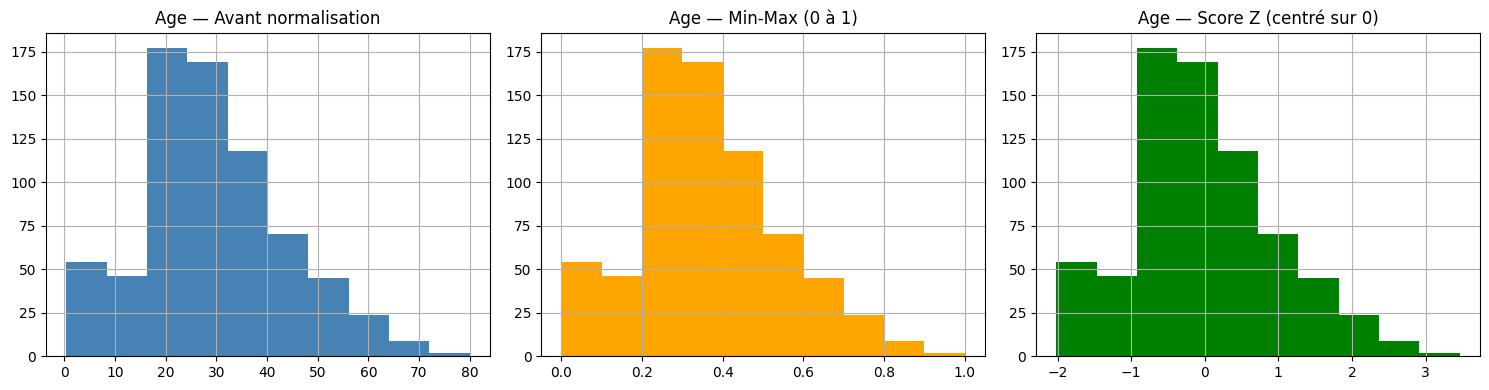

In [3]:
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df = df[['Age', 'Fare']].dropna()

# On applique les deux normalisations
scaler_mm = MinMaxScaler()
scaler_z  = StandardScaler()

df['Age_minmax'] = scaler_mm.fit_transform(df[['Age']])
df['Age_zscore'] = scaler_z.fit_transform(df[['Age']])

# On compare visuellement avant / après
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Avant
df['Age'].hist(ax=axes[0], color='steelblue')
axes[0].set_title('Age — Avant normalisation')

# Après Min-Max
df['Age_minmax'].hist(ax=axes[1], color='orange')
axes[1].set_title('Age — Min-Max (0 à 1)')

# Après Score Z
df['Age_zscore'].hist(ax=axes[2], color='green')
axes[2].set_title('Age — Score Z (centré sur 0)')

plt.tight_layout()
plt.show()

# La forme des histogrammes reste la même !
# Seule l'échelle change — c'est tout l'intérêt de la normalisation

Exercice 4 — ACP + Agrégation (Titanic)

In [ ]:
from sklearn.decomposition import PCA

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df = df[['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']].dropna()

# On normalise AVANT de faire l'ACP — c'est obligatoire
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# L'ACP réduit 5 colonnes en 2 colonnes
# On garde l'essentiel de l'info en simplifiant
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"Info conservée : {sum(pca.explained_variance_ratio_)*100:.1f}%")
# Tu verras un pourcentage — plus c'est haut, mieux c'est

# --- Agrégation par classe ---
df_original = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Moyenne de survie, âge et tarif par classe
agregation = df_original.groupby('Pclass').agg(
    survie_moyenne = ('Survived', 'mean'),
    age_moyen      = ('Age', 'mean'),
    tarif_moyen    = ('Fare', 'mean')
).round(2)

print(agregation)
# Tu verras clairement que la 1ère classe a beaucoup plus survécu 

Info conservée : 67.1%
        survie_moyenne  age_moyen  tarif_moyen
Pclass                                        
1                 0.63      38.23        84.15
2                 0.47      29.88        20.66
3                 0.24      25.14        13.68


Exercice 5 — Normalisation ventes supermarché

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/supermarket_sales.csv')

# On regarde les colonnes disponibles
print(df.columns)

scaler = MinMaxScaler()

# On crée de nouvelles colonnes normalisées
# Comme ça on garde les valeurs originales ET les valeurs normalisées
df[['Sales_normalized', 'Profit_normalized']] = scaler.fit_transform(
    df[['Sales', 'Profit']]  # adapte selon les noms de colonnes réels
)

print(df[['Sales', 'Sales_normalized', 'Profit', 'Profit_normalized']].head())
# Les valeurs normalisées seront toutes entre 0 et 1

HTTPError: HTTP Error 404: Not Found

Exercice 6 — Qualité de l'air en Inde

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/air_quality_india.csv')

# On convertit la colonne Date en vrai format date
# Sans ça Python la traite comme du texte simple
df['Date'] = pd.to_datetime(df['Date'])

# On extrait le mois depuis la date
df['Month'] = df['Date'].dt.to_period('M')

# On groupe par lieu ET par mois
# Puis on calcule la moyenne de chaque polluant
agregation = df.groupby(['City', 'Month']).agg(
    PM25_moyen = ('PM2.5', 'mean'),
    PM10_moyen = ('PM10', 'mean'),
    NO2_moyen  = ('NO2',  'mean')
).round(2)

print(agregation.head(10))

# Visualiser une ville en particulier
ville = agregation.loc['Delhi']
ville['PM25_moyen'].plot(figsize=(12, 4), title='PM2.5 à Delhi par mois')
plt.xlabel('Mois')
plt.ylabel('PM2.5 moyen')
plt.show()
# Tu pourras voir les mois où la pollution est la pire 😷

HTTPError: HTTP Error 404: Not Found